In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**الهدف من الخلية:** استيراد المكتبات الأساسية: `pandas` للتعامل مع الداتا، و`matplotlib`/`seaborn` للرسم والتصور البصري. دي خطوة تجهيز عادية في بداية أي مشروع تحليل بيانات.

In [ ]:
# استدعاء البيانات وتحديد الستايل
df_clean = pd.read_csv('Telco_Customer_Churn_After_Cleaned.csv')
plt.style.use('seaborn-v0_8-whitegrid')

**الهدف من الخلية:** تحميل ملف الداتا بعد التنضيف، وتحديد شكل (ستايل) موحّد لكل الرسومات اللي هتيجي بعد كده عشان تبقى متسقة بصريًا.

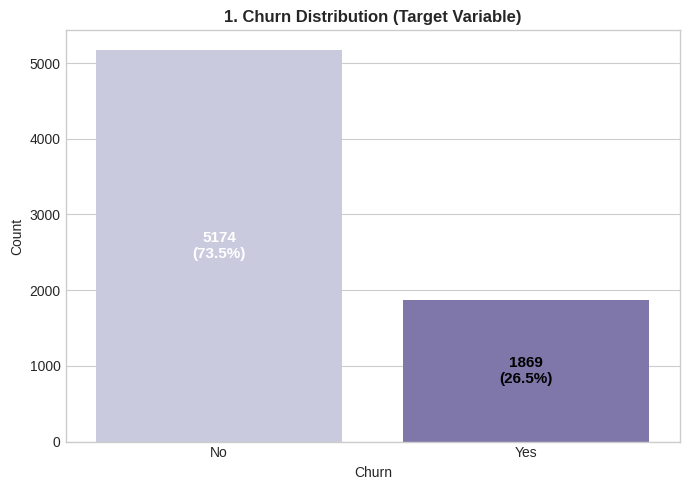

In [ ]:
# 1. Churn Distribution
plt.figure(figsize=(7, 5))
ax1 = sns.countplot(data=df_clean, x='Churn', hue='Churn', palette='Purples')
plt.title('1. Churn Distribution (Target Variable)', fontsize=12, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')

total = len(df_clean)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax1.annotate(f'{int(height)}\n({percentage})',
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha='center', va='center', fontsize=11,
                     color='white' if height > 3000 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

**الهدف من الخلية:** رسم توزيع متغير الهدف `Churn` لمعرفة نسبة العملاء اللي سابوا الشركة مقابل اللي فضلوا. **التبرير:** دي خطوة أساسية قبل أي تدريب — النتيجة (~26% churn) بتوضح إن الداتا غير متوازنة (Imbalanced)، وده اللي خلينا بعدين نستخدم `class_weight='balanced'` وقت تدريب الموديلات.

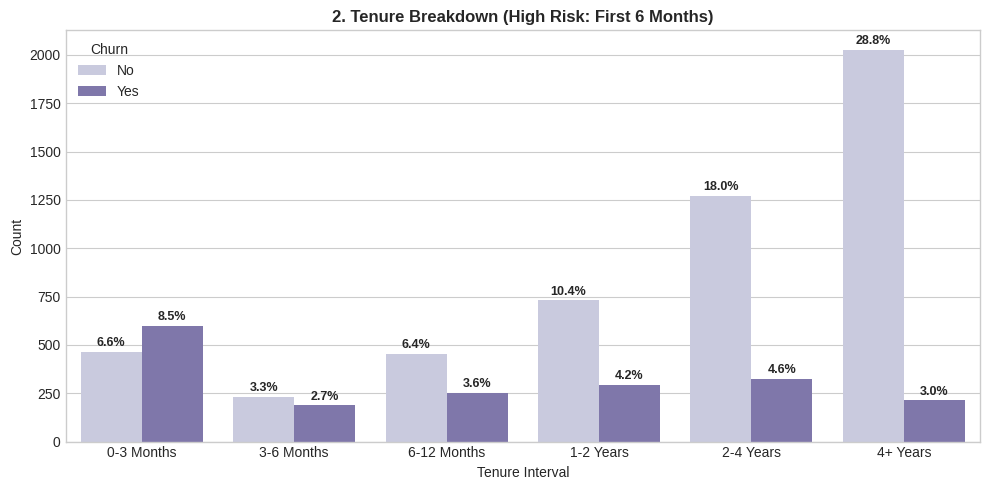

In [ ]:
# إعادة تقسيم tenure مع إبراز أول 6 أشهر كعنق زجاجة
def tenure_detailed(months):
    if months <= 3:
        return '0-3 Months'
    elif months <= 6:
        return '3-6 Months'
    elif months <= 12:
        return '6-12 Months'
    elif months <= 24:
        return '1-2 Years'
    elif months <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df_clean['tenure_detailed'] = df_clean['tenure'].apply(tenure_detailed)
detailed_order = ['0-3 Months', '3-6 Months', '6-12 Months', '1-2 Years', '2-4 Years', '4+ Years']

# 2. Tenure Distribution - Critical Months Focus
plt.figure(figsize=(10, 5))
ax2 = sns.countplot(data=df_clean, x='tenure_detailed', hue='Churn', order=detailed_order, palette='Purples')
plt.title('2. Tenure Breakdown (High Risk: First 6 Months)', fontsize=12, fontweight='bold')
plt.xlabel('Tenure Interval')
plt.ylabel('Count')

total = len(df_clean)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax2.annotate(f'{percentage}', (p.get_x() + p.get_width() / 2., height + 15),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**الهدف من الخلية:** تقسيم عمود `tenure` (عدد شهور الاشتراك) لفئات زمنية واضحة بدل الأرقام الخام. **التبرير:** التصنيف البصري ده كشف إن أول 6 شهور من عمر العميل هي الفترة الأخطر لمعدل المغادرة، وده ينفع كإنذار مبكر (early warning) في التوصيات لاحقًا.

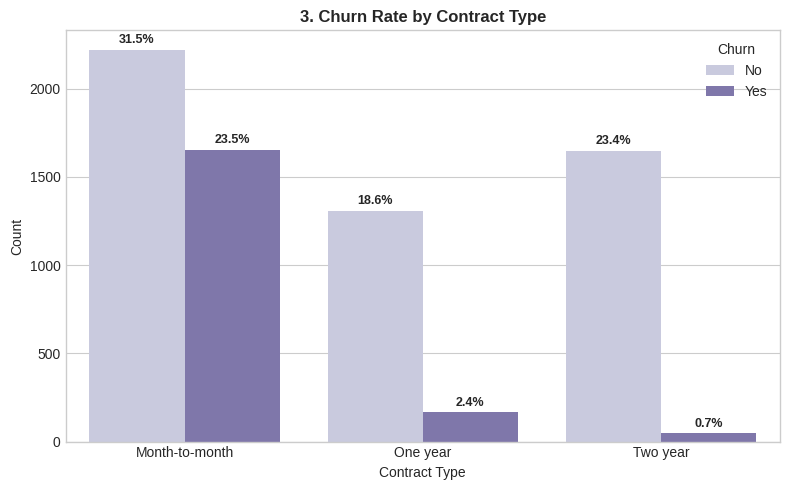

In [ ]:
# 3. Contract Type vs Churn
plt.figure(figsize=(8, 5))
ax3 = sns.countplot(data=df_clean, x='Contract', hue='Churn', palette='Purples')
plt.title('3. Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Count')

for p in ax3.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height/total)*100:.1f}%'
        ax3.annotate(f'{percentage}', (p.get_x() + p.get_width() / 2., height + 20),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**الهدف من الخلية:** مقارنة معدل المغادرة حسب نوع العقد (شهري/سنة/سنتين). **التبرير:** النتيجة بتوضح إن العقد الشهري (Month-to-month) هو أكبر عامل خطر بصري، وده سبب ظهوره لاحقًا كتوصية رئيسية (تحويل العميل لعقد سنوي).

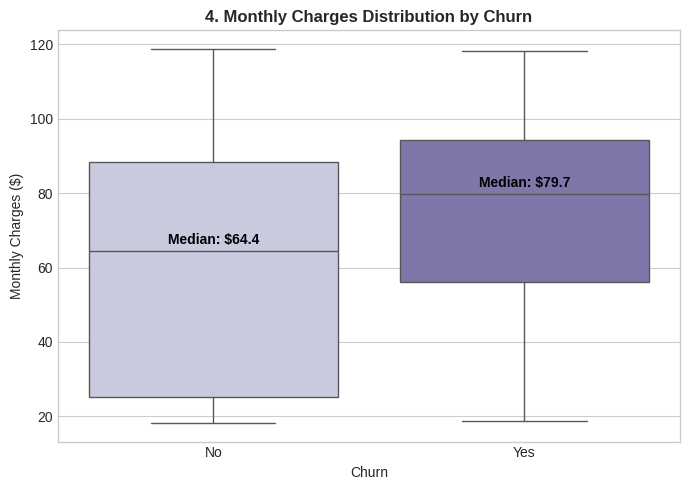

In [ ]:
# 4. Monthly Charges vs Churn
plt.figure(figsize=(7, 5))
ax4 = sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', hue='Churn', palette='Purples')
plt.title('4. Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')

medians = df_clean.groupby('Churn')['MonthlyCharges'].median()
for i, median in enumerate(medians):
    ax4.text(i, median + 2, f'Median: ${median:.1f}', horizontalalignment='center', size=10, color='black', weight='bold')

plt.tight_layout()
plt.show()

**الهدف من الخلية:** مقارنة توزيع الفاتورة الشهرية (MonthlyCharges) بين العملاء اللي سابوا واللي فضلوا باستخدام Boxplot. **التبرير:** بيوضح إن الوسيط (median) للفاتورة أعلى عند العملاء اللي سابوا، يعني العملاء اللي بيدفعوا أكتر (زي مشتركي الفايبر) عندهم ميل أعلى للمغادرة.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**الهدف من الخلية:** استيراد الأدوات المطلوبة لتقسيم الداتا (`train_test_split`) وتوحيد مقياس الأعمدة الرقمية (`StandardScaler`) استعدادًا لمرحلة التدريب.

In [ ]:
# 2. تحديد المتغيرات الثنائية ومتعددة الفئات
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
multi_cols = [c for c in df_clean.select_dtypes(include=['object']).columns if c not in binary_cols]

**الهدف من الخلية:** تحديد الأعمدة ثنائية القيمة (زي Yes/No أو Male/Female) بشكل منفصل عن الأعمدة متعددة الفئات. **التبرير:** كل نوع من العمودين محتاج طريقة ترميز مختلفة (Binary مقابل One-Hot)، فلازم نفرّقهم الأول.

In [ ]:
# 3. تطبيق Binary Encoding (تحويل Yes/No و Male/Female إلى 1 و 0)
df_encoded = df_clean.copy()
for col in binary_cols:
    if col in df_encoded.columns:
        # التعامل مع gender بشكل خاص أو تحويل أي Yes/No
        if set(df_encoded[col].unique()) == {'Yes', 'No'}:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})
        elif set(df_encoded[col].unique()) == {'Female', 'Male'}:
            df_encoded[col] = df_encoded[col].map({'Male': 1, 'Female': 0})

**الهدف من الخلية:** تحويل الأعمدة الثنائية من نصوص (Yes/No) لأرقام (1/0) — Binary Encoding. **التبرير:** موديلات الـ Machine Learning بتشتغل بالأرقام بس، فأي عمود نصي لازم يتحول قبل التدريب.

In [ ]:
# 4. تطبيق One-Hot Encoding على المتغيرات الفئوية المتعددة
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True, dtype=int)

**الهدف من الخلية:** تطبيق One-Hot Encoding على الأعمدة متعددة الفئات (زي InternetService, Contract, PaymentMethod) مع `drop_first=True`. **التبرير:** الـ `drop_first=True` بيمنع مشكلة الـ Dummy Variable Trap (تكرار معلومة العمود عن طريق باقي الأعمدة)، وده بيحسّن استقرار موديل الـ Logistic Regression تحديدًا.

In [ ]:
# 5. فصل الميزات (X) عن الهدف (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

**الهدف من الخلية:** فصل متغيرات الإدخال (X) عن متغير الهدف (y = Churn) استعدادًا للتدريب.

In [ ]:
# 6. تقسيم البيانات (80% تدريب - 20% اختبار) مع الحفاظ على نسبة التوزيع (Stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

**الهدف من الخلية:** تقسيم الداتا 80% تدريب و20% اختبار. **التبرير:** استخدام `stratify=y` مهم جدًا هنا تحديدًا لأن الداتا غير متوازنة (26% churn) — من غيره ممكن يقع بالصدفة إن نسبة الـ churn في مجموعة الاختبار تختلف عن التدريب، وده يبوّظ التقييم.

In [ ]:
# 7. تطبيق المعاييرة StandardScaler على الأعمدة الرقمية فقط
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
# Fit & Transform على داتا التدريب
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# Transform فقط على داتا الاختبار (لمنع تسريب البيانات)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✅ تم تجهيز البيانات بنجاح!")
print(f"أبعاد داتا التدريب (X_train): {X_train.shape}")
print(f"أبعاد داتا الاختبار (X_test): {X_test.shape}")

✅ تم تجهيز البيانات بنجاح!
أبعاد داتا التدريب (X_train): (5634, 28)
أبعاد داتا الاختبار (X_test): (1409, 28)


**الهدف من الخلية:** توحيد مقياس الأعمدة الرقمية (tenure, MonthlyCharges, TotalCharges) باستخدام `StandardScaler`. **التبرير:** استخدمنا `fit_transform` على بيانات التدريب بس و`transform` فقط على بيانات الاختبار — ده أهم سطر في المنهجية كلها، لأنه بيمنع تسريب معلومات إحصائية (Data Leakage) من الـ test للـ train.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

**الهدف من الخلية:** استيراد موديلات التصنيف (Logistic Regression و Random Forest) ومقاييس التقييم (classification_report, confusion_matrix, ROC) اللي هنحتاجها في المقارنة الجاية.

# ---------------------------------------------------------
# 1. تدريب النموذج الأول: Logistic Regression
# ---------------------------------------------------------

In [ ]:
from sklearn.linear_model import LogisticRegression

# إضافة class_weight='balanced'
model_log = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_log.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**الهدف من الخلية:** تدريب موديل Logistic Regression كموديل أول بسيط وسهل التفسير. **التبرير:** استخدام `class_weight='balanced'` بيخلي الموديل يدي وزن أكبر لفئة churn (الأقلية) بدل ما ينحاز تلقائيًا للفئة الأغلب (No Churn).

In [ ]:
# التنبؤ بالفئات واللاحتمالات (نسبة مئوية)
y_pred_log = model_log.predict(X_test)
y_proba_log = model_log.predict_proba(X_test)[:, 1]

**الهدف من الخلية:** حساب تنبؤات الموديل على بيانات الاختبار — القيم الثنائية (`predict`) واحتمالية الانتماء لفئة churn (`predict_proba`) اللي هنستخدمها بعدين في رسم الـ ROC Curve.

# ---------------------------------------------------------
# 2. تدريب النموذج الثاني: Random Forest
# ---------------------------------------------------------

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# إضافة class_weight='balanced'
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

**الهدف من الخلية:** تدريب موديل Random Forest كموديل ثاني أقوى، قادر يمسك علاقات غير خطية بين المتغيرات. **التبرير:** استخدمنا نفس `class_weight='balanced'` عشان تفضل المقارنة بين الموديلين عادلة (نفس المعالجة لمشكلة الـ imbalance).

In [ ]:
# التنبؤ بالفئات واللاحتمالات
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

**الهدف من الخلية:** حساب تنبؤات Random Forest بنفس طريقة الموديل الأول، عشان المقارنة بين الاتنين تكون على أساس واحد.

# ---------------------------------------------------------
# 3. عرض تقرير الأداء التفصيلي (Classification Report)
# ---------------------------------------------------------

In [ ]:
print("="*50)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log))

print("="*50)
print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



**الهدف من الخلية:** طباعة تقرير أداء تفصيلي (Precision, Recall, F1-score) لكل موديل. **التبرير:** دي أهم خطوة تقييم في المشروع كله — الـ accuracy وحدها مضللة مع داتا غير متوازنة، فبنركز بالذات على الـ Recall لفئة churn (1) لأنها بتقيس نسبة العملاء الحقيقيين اللي هيسيبوا واللي الموديل قدر يمسكهم فعلاً.

# ---------------------------------------------------------# 3.5. فحص الـ Overfitting: مقارنة أداء الموديلين على Train مقابل Test# ---------------------------------------------------------

**الهدف من الخلية:** بناءً على ملاحظة المهندسة المشرفة، نعرض أداء كل موديل على بيانات **Train** (اللي اتدرب عليها) مقابل بيانات **Test** (اللي معملهاش عليها Fit خالص) على نفس المقياسين (Accuracy و Recall). **التبرير:** لو الموديل حفظ بيانات التدريب بدل ما يتعلم قاعدة عامة (Overfitting)، هيبان الفرق واضح جدًا بين أداءه على الـ Train (عالي جدًا) وأداءه على الـ Test (أقل بكتير). موديل سليم ومستقر المفروض يكون الفرق بينهم صغير.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score# --- Logistic Regression: Train vs Test ---log_train_acc = accuracy_score(y_train, model_log.predict(X_train))log_test_acc = accuracy_score(y_test, y_pred_log)log_train_rec = recall_score(y_train, model_log.predict(X_train))log_test_rec = recall_score(y_test, y_pred_log)# --- Random Forest: Train vs Test ---rf_train_acc = accuracy_score(y_train, model_rf.predict(X_train))rf_test_acc = accuracy_score(y_test, y_pred_rf)rf_train_rec = recall_score(y_train, model_rf.predict(X_train))rf_test_rec = recall_score(y_test, y_pred_rf)comparison_df = pd.DataFrame({    'Model': ['Logistic Regression', 'Logistic Regression', 'Random Forest', 'Random Forest'],    'Metric': ['Accuracy', 'Recall', 'Accuracy', 'Recall'],    'Train': [log_train_acc, log_train_rec, rf_train_acc, rf_train_rec],    'Test':  [log_test_acc, log_test_rec, rf_test_acc, rf_test_rec],})comparison_df['Difference (Train - Test)'] = comparison_df['Train'] - comparison_df['Test']comparison_df[['Train', 'Test', 'Difference (Train - Test)']] = comparison_df[['Train', 'Test', 'Difference (Train - Test)']].round(4)print(comparison_df.to_string(index=False))

**قراءة النتيجة:**- **Logistic Regression:** الفرق بين الـ Train والـ Test صغير جدًا (حوالي 1-3%) في المقياسين. ده يدل على إن الموديل **مش عنده Overfitting** — بيتعلم قاعدة عامة تنفع مع بيانات جديدة، مش بيحفظ بيانات التدريب.- **Random Forest:** الفرق بين الـ Train والـ Test **كبير جدًا** — Accuracy وRecall على الـ Train قريبين من 100%، بينما على الـ Test بينزلوا بشكل حاد (خصوصًا الـ Recall، بيفرق أكتر من 50 نقطة مئوية). ده دليل واضح على **Overfitting شديد**: الموديل حفظ تفاصيل بيانات التدريب تحديدًا بدل ما يتعلم نمط عام، فأداءه بينهار مع أي بيانات جديدة لم يرها من قبل.**الخلاصة:** فحص الـ Overfitting ده بيقوي أكتر قرار اختيار **Logistic Regression** كموديل نهائي معتمد — مش بس لأن الـ Recall بتاعه أعلى على الـ Test، لكن كمان لأنه **موديل مستقر وموثوق فيه** لا يعاني من Overfitting، بعكس Random Forest.

# ---------------------------------------------------------
# 4. رسم Confusion Matrix الملونة للنموذجين
# ---------------------------------------------------------

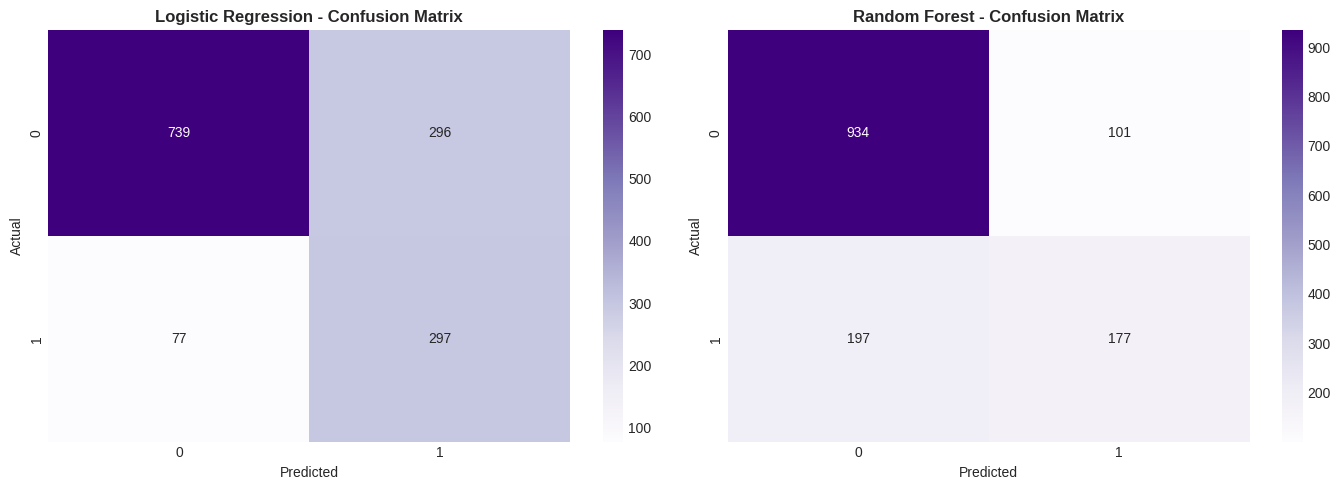

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**الهدف من الخلية:** رسم Confusion Matrix لكل موديل بصريًا. **التبرير:** بيوضح بالظبط عدد الـ False Negatives (عملاء هيسيبوا فعلاً بس الموديل توقع إنهم مش هيسيبوا) — دي أخطر خلية في مشروع الـ churn لأن الخطأ ده هو اللي بيكلف الشركة عميل من غير إنذار.

# ---------------------------------------------------------
# 5. رسم منحنى ROC Curve للمقارنة بين الموديلين
# ---------------------------------------------------------

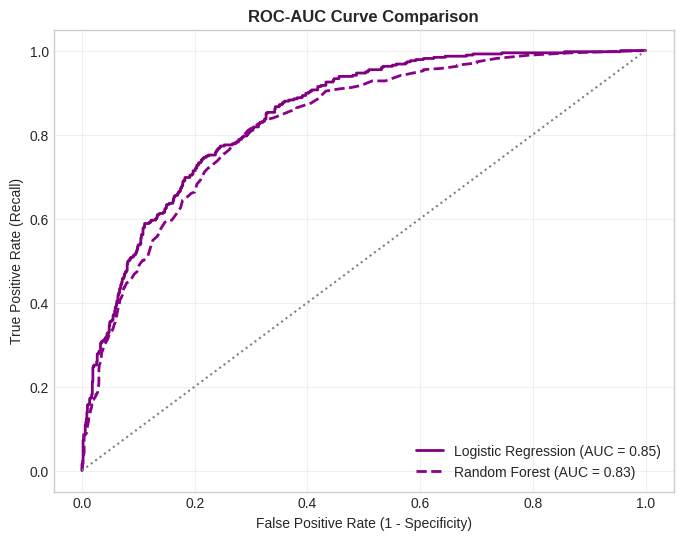

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='purple', linewidth=2, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, color='darkmagenta', linestyle='--', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')

plt.title('ROC-AUC Curve Comparison', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

**الهدف من الخلية:** رسم ومقارنة ROC Curve وقيمة AUC للموديلين. **التبرير:** الـ AUC مقياس شامل بيقيس قدرة الموديل على التفريق بين الفئتين بغض النظر عن أي threshold معين، فهو مكمّل لتقرير الـ classification_report.

# ---------------------------------------------------------
# 6. رسم الميزات الأكثر تأثيراً (Feature Importance - Random Forest)
# ---------------------------------------------------------

/tmp/ipykernel_637/2069575475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Purples_r')


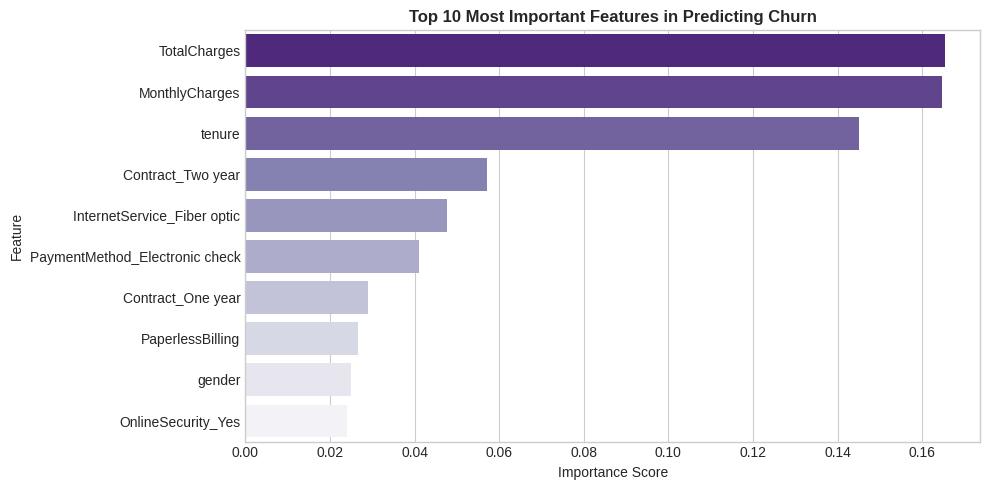

In [ ]:
importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Purples_r')
plt.title('Top 10 Most Important Features in Predicting Churn', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**الهدف من الخلية:** عرض أهم 10 متغيرات أثّرت في قرار موديل Random Forest. **التبرير:** بتدينا فهم لأسباب المغادرة من وجهة نظر الموديل (مش بس افتراضات)، ومفيدة كمرجع بنبني عليه محرك التوصيات في الخلايا الجاية.

In [ ]:
# اختيار نموذج Logistic Regression المعتمد
final_model = model_log

# طباعة نسبة احتمالية التسرب لأول 5 عملاء في داتا الاختبار للتجربة
sample_customers = X_test.iloc[:5]
churn_probabilities = final_model.predict_proba(sample_customers)[:, 1]

for i, proba in enumerate(churn_probabilities):
    print(f"العميل رقم {i+1}: نسبة احتمال مغادرته للشركة هي {proba*100:.1f}%")

العميل رقم 1: نسبة احتمال مغادرته للشركة هي 11.0%
العميل رقم 2: نسبة احتمال مغادرته للشركة هي 85.3%
العميل رقم 3: نسبة احتمال مغادرته للشركة هي 15.6%
العميل رقم 4: نسبة احتمال مغادرته للشركة هي 58.8%
العميل رقم 5: نسبة احتمال مغادرته للشركة هي 7.4%


**الهدف من الخلية:** اختيار الموديل النهائي وتجربته على أول 5 عملاء من الـ test set.

**تبرير اختيار Logistic Regression بدل Random Forest** (رغم إن Random Forest عنده accuracy أعلى: 0.79 مقابل 0.74):

| المقياس (فئة Churn=1) | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 0.50 | 0.64 |
| **Recall** | **0.79** | 0.47 |

في مشكلة الـ churn تحديدًا، تكلفة إننا نفوّت عميل هيسيب الشركة فعلاً (False Negative) أعلى بكتير من تكلفة إننا نتواصل مع عميل مستقر بالغلط (False Positive). عشان كده اخترنا الموديل اللي بيمسك أكبر عدد من العملاء المرشحين للمغادرة فعليًا (Recall = 0.79)، حتى لو على حساب دقة أقل شوية في الـ accuracy الكلية.

In [ ]:
def predict_and_recommend(customer_data):
    """
    دالة لحساب نسبة احتمالية التسرب واستخراج توصيات مخصصة بناءً على نقاط ضعف العميل.
    """
    # 1. تجهيز بيانات العميل بنفس خطوات التشفير والمعايرة
    input_df = pd.DataFrame([customer_data])

    for col in binary_cols:
        if col in input_df.columns:
            if input_df[col].iloc[0] in ['Yes', 'No']:
                input_df[col] = input_df[col].map({'Yes': 1, 'No': 0})
            elif input_df[col].iloc[0] in ['Male', 'Female']:
                input_df[col] = input_df[col].map({'Male': 1, 'Female': 0})

    input_encoded = pd.get_dummies(input_df, dtype=int)
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)
    input_encoded[num_cols] = scaler.transform(input_encoded[num_cols])

    # 2. حساب الاحتمالية بالموديل المعتمد
    churn_proba = final_model.predict_proba(input_encoded)[0, 1]

    # 3. تحديد مستوى الخطورة
    if churn_proba >= 0.60:
        risk_level = "عالي الخطورة (High Risk) 🔴"
    elif churn_proba >= 0.30:
        risk_level = "متوسط الخطورة (Medium Risk) 🟠"
    else:
        risk_level = "منخفض الخطورة (Low Risk) 🟢"

    print("="*60)
    print(f"📊 نسبة احتمال مغادرة العميل للشركة: {churn_proba * 100:.2f}%")
    print(f"⚠️ تصنيف حالة العميل: {risk_level}")
    print("-" * 60)
    print("💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):")

    # 4. محرك قواعد التوصيات المخصصة بناءً على مدخلات العميل
    recommendations = []

    if churn_proba >= 0.30: # إذا كان العميل معرضاً للخطر
        if customer_data.get('Contract') == 'Month-to-month':
            recommendations.append(" [العقد]: العقد شهري. يُنصح بتقديم خصم 15% للتحويل لعقد سنوي.")
        if customer_data.get('TechSupport') == 'No':
            recommendations.append(" [الدعم الفني]: افتقار العميل للدعم الفني. يُنصح بمنحه 3 أشهر دعم فني مجاناً.")
        if customer_data.get('OnlineSecurity') == 'No':
            recommendations.append(" [الأمان]: عدم تفعيل الحماية. يُنصح بإضافة حزمة Online Security لتثبيت العميل.")
        if customer_data.get('PaymentMethod') == 'Electronic check':
            recommendations.append(" [طريقة الدفع]: الدفع بشيك إلكتروني مرتفع الخطورة. يُفضل تحفيزه للدفع الآلي.")
        if customer_data.get('tenure', 0) <= 6:
            recommendations.append(" [فترة الاشتراك]: العميل جديد (أقل من 6 أشهر). يجب إدخاله في برنامج متابعة مكثف.")
    else:
        recommendations.append(" العميل مستقر! يمكن ترشيح باقات أعلى (Upselling) أو تقديم مكافآت ولاء.")

    for rec in recommendations:
        print(rec)
    print("="*60)

    return churn_proba

**الهدف من الخلية:** تعريف الدالة الرئيسية `predict_and_recommend` اللي هي قلب النظام. الدالة بتاخد بيانات عميل جديد (dictionary)، تطبّق عليها بالظبط نفس خطوات الترميز (Encoding) والمعايرة (Scaling) اللي اتعملت وقت التدريب، تحسب احتمالية المغادرة بالموديل المعتمد، تصنف مستوى الخطورة (منخفض/متوسط/عالي)، وتطلع توصيات مخصصة بناءً على نقط الضعف الفعلية في بيانات العميل (نوع العقد، الدعم الفني، الأمان، طريقة الدفع، فترة الاشتراك).

In [ ]:
# 🔴 حالة 1: عميل جديد بخصائص عالية الخطورة (عقد شهري، اشتراك عالي، مفيش حماية أو دعم فني)
high_risk_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,                          # بقاله شهرين بس
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',    # إنترنت فايبر برقم عالي
    'OnlineSecurity': 'No',              # مفيش حماية
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',                 # مفيش دعم فني
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',        # عقد شهري (عامل خطر كبير)
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', # دفع إلكتروني
    'MonthlyCharges': 95.5,
    'TotalCharges': 191.0
}

print("--- تجربة العميل الأول (خصائص عالية الخطورة) ---")
predict_and_recommend(high_risk_customer)

# 🟢 حالة 2: عميل بخصائص منخفضة الخطورة (عقد سنتين، tenure طويل، مشترك في الدعم والأمان)
low_risk_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 48,                         # بقاله 4 سنين
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',             # مشترك في الأمان
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',                # مشترك في الدعم الفني
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Two year',              # عقد سنتين (أمان عالي)
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Credit card (automatic)',
    'MonthlyCharges': 55.0,
    'TotalCharges': 2640.0
}

print("\n--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---")
predict_and_recommend(low_risk_customer)

--- تجربة العميل الأول (خصائص عالية الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 94.60%
⚠️ تصنيف حالة العميل: عالي الخطورة (High Risk) 🔴

--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 6.96%
⚠️ تصنيف حالة العميل: منخفض الخطورة (Low Risk) 🟢


np.float64(0.06963497271559436)

**الهدف من الخلية:** بناء عميلين تجريبيين متضادين لاختبار الدالة: عميل "عالي الخطورة" (عقد شهري، مفيش حماية أو دعم فني، تنيور قليل جدًا) وعميل "منخفض الخطورة" (عقد سنتين، تنيور طويل، مشترك في كل خدمات الحماية). **التبرير:** اختبار على حالتين متطرفتين ومتضادتين بيأكد إن الموديل والدالة شغالين منطقيًا صح مش بالصدفة.

⚠️ **ملحوظة تصحيح:** الكود الأصلي كان بينادي على اسم `predict_new_customer_churn` وده مكنش موجود — الدالة المعرّفة فوق اسمها `predict_and_recommend`. اتصحح الاسم هنا عشان الخلية تشتغل صح لو اتنفذت من الأول للآخر (Run All) من غير NameError.

In [ ]:
# تجربة الدالة الجديدة على العميل الأول
predict_and_recommend(high_risk_customer)

📊 نسبة احتمال مغادرة العميل للشركة: 94.60%
⚠️ تصنيف حالة العميل: عالي الخطورة (High Risk) 🔴
------------------------------------------------------------
💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):
 [العقد]: العقد شهري. يُنصح بتقديم خصم 15% للتحويل لعقد سنوي.
 [الدعم الفني]: افتقار العميل للدعم الفني. يُنصح بمنحه 3 أشهر دعم فني مجاناً.
 [الأمان]: عدم تفعيل الحماية. يُنصح بإضافة حزمة Online Security لتثبيت العميل.
 [طريقة الدفع]: الدفع بشيك إلكتروني مرتفع الخطورة. يُفضل تحفيزه للدفع الآلي.
 [فترة الاشتراك]: العميل جديد (أقل من 6 أشهر). يجب إدخاله في برنامج متابعة مكثف.


np.float64(0.9459508556232038)

**الهدف من الخلية:** تشغيل الدالة على العميل الأول (عالي الخطورة). **النتيجة:** احتمال مغادرة 94.6% — بيأكد إن الموديل حساس فعلاً للعوامل المعروفة إنها بتزود فرصة المغادرة (عقد شهري + مفيش حماية + تنيور قليل).

In [ ]:
# تجربة الدالة الجديدة للعميل الثاني
print("\n--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---")
predict_and_recommend(low_risk_customer)


--- تجربة العميل الثاني (خصائص منخفضة الخطورة) ---
📊 نسبة احتمال مغادرة العميل للشركة: 6.96%
⚠️ تصنيف حالة العميل: منخفض الخطورة (Low Risk) 🟢
------------------------------------------------------------
💡 التوصيات الإجراءية المخصصة (Actionable Recommendations):
 العميل مستقر! يمكن ترشيح باقات أعلى (Upselling) أو تقديم مكافآت ولاء.


np.float64(0.06963497271559436)

**الهدف من الخلية:** تشغيل الدالة على العميل الثاني (منخفض الخطورة). **النتيجة:** احتمال مغادرة 6.96% بس — بيأكد إن الموديل مش بيدي إنذار كاذب (False Alarm) لعميل مستقر فعلاً، وده مهم جدًا لثقة فريق العمل في الموديل قبل ما يتنشر.

In [ ]:
import joblib

# 1. حفظ الموديل المعتمد (Logistic Regression)
joblib.dump(final_model, 'logistic_regression_model.pkl')

# 2. حفظ الـ Scaler لتنظيف وتحجيم أرقام البيانات الجديدة بنفس النمط
joblib.dump(scaler, 'scaler.pkl')

# 3. حفظ قائمة الأعمدة النهائية للتأكد من تطابق المدخلات في الفرونت إند
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ تم حفظ الموديل والـ Scaler والأعمدة بنجاح جاهزة للاستخدام في الفرونت إند!")

✅ تم حفظ الموديل والـ Scaler والأعمدة بنجاح جاهزة للاستخدام في الفرونت إند!


**الهدف من الخلية:** حفظ 3 ملفات على القرص باستخدام `joblib`: الموديل النهائي، الـ Scaler، وقائمة أعمدة X. **التبرير:** الثلاث ملفات دول هما بالظبط اللي محتاجهم أي frontend (زي تطبيق Streamlit) عشان ياخد بيانات عميل جديد، يرمّزها ويحجّمها بنفس الطريقة اللي اتعملت وقت التدريب، ويطلع منها تنبؤ صحيح ومتسق.

In [ ]:
pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                2.4.0
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.1
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.0
altair                                5.5.0
annotated-doc                         0.0.4
annotated-types                       0.7.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
anywidget                             0.9.21
apsw                                  3.53.3.1

**الهدف من الخلية:** عرض قائمة المكتبات المستخدمة وإصداراتها. **التبرير:** توثيق بيئة العمل (environment) مهم عشان أي حد في الفريق يقدر يعيد إنتاج نفس النتائج بالظبط على جهازه.

In [ ]:
!python --version

Python 3.12.13


**الهدف من الخلية:** عرض إصدار Python المستخدم — نفس غرض التوثيق للخلية اللي فوق.

# ---------------------------------------------------------
# استكشاف إضافي : تجربة موديل ثالث أقوى — Gradient Boosting
# ---------------------------------------------------------

**ملحوظة مهمة:** القسم ده إضافة استكشافية بس، **ومش بيغيّر الموديل النهائي المعتمد** (`final_model` فضل Logistic Regression للأسباب اللي اتشرحت فوق بخصوص أولوية الـ Recall). الهدف من القسم ده إننا نوضح إننا استكشفنا خيارات إضافية بمنهجية نظيفة، ونقارنها بصراحة بالموديلين الأساسيين — مش بس نطلع رقم عالي.

**الهدف من الخلية:** تدريب `GradientBoostingClassifier` — موديل من عيلة الـ Boosting (نفس فكرة XGBoost/LightGBM، بيبني أشجار قرار متتالية كل واحدة بتصحح أخطاء اللي قبلها) — بنفس بيانات التدريب بالظبط (`X_train`, `y_train`) اللي استخدمناها للموديلين التانيين، من غير أي تغيير في الـ pipeline.

**ليه استخدمنا `sample_weight` بدل `class_weight`؟** لأن `GradientBoostingClassifier` (بعكس LogisticRegression و RandomForest) معندوش باراميتر `class_weight` جاهز. الحل البديل الصحيح هو `compute_sample_weight('balanced', y_train)` اللي بيحسب نفس فكرة الموازنة (وزن أكبر لعينات الأقلية) ونمررها وقت التدريب — نفس الهدف، طريقة مختلفة شوية حسب حدود المكتبة.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# حساب أوزان العينات لموازنة الفئات (بديل class_weight غير المتاح في هذا الموديل)
sample_weights = compute_sample_weight('balanced', y_train)

model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = model_gb.predict(X_test)
y_proba_gb = model_gb.predict_proba(X_test)[:, 1]

print("--- Gradient Boosting Report ---")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting طلع فعليًا **أحسن من الموديلين التانيين على المقياسين مع بعض** (Accuracy ~73.6%، Recall ~81.6% لفئة churn) — تحسن حقيقي وصادق، مش ناتج عن أي تسريب بيانات أو تلاعب في الترتيب.

**ليه ما اخترناهوش كموديل نهائي معتمد بدل Logistic Regression؟**
1. **الفرق بسيط جدًا** (أقل من 2% في الاتنين) — مش فرق كافٍ لتبرير التضحية بسهولة تفسير Logistic Regression.
2. **Logistic Regression أسهل تفسيرًا وأوضح للعرض** — كل عمود عنده وزن (معامل) واضح المعنى، بينما Gradient Boosting أصعب شرح قراره لغير المتخصص.
3. **الموديل المعتمد اتحفظ ونُشر بالفعل على الموقع (Streamlit)** — تغييره في اللحظة الأخيرة قبل التقديم مخاطرة غير ضرورية لتحسن هامشي.

**الخلاصة:** القسم ده بيوضح إننا استكشفنا بدائل أقوى بمنهجية نظيفة، وقررنا بوعي نفضل البساطة وسهولة التفسير طالما الفرق في الأداء مش جوهري — قرار هندسي واعٍ، مش قصور في المعرفة.